In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("data/processed/analysis_dataset.csv")
print("Loaded:", df.shape[0], "rows,", df.shape[1], "columns")
df.head()

Loaded: 475 rows, 19 columns


,year,dimension,subgroup,pct_5aday,pct_active,pct_inactive,pct_obese,pct_overweight_obese,england_pct_5aday,england_pct_active,england_pct_inactive,england_pct_obese,england_pct_overweight_obese,above_national_obesity,activity_gap,obesity_gap,diet_gap,deprivation_rank,year_numeric
0,2015/16,Age,18-24 yrs,NaN,NaN,NaN,9.70201,33.45900,NaN,66.1336,22.33011,22.6262,61.24163,0,NaN,-27.78263,NaN,NaN,2015
1,2015/16,Age,19-24 yrs,NaN,77.52994,14.20456,NaN,NaN,NaN,66.1336,22.33011,22.6262,61.24163,0,11.39634,NaN,NaN,NaN,2015
2,2015/16,Age,25-34 yrs,NaN,70.97007,17.62553,17.07362,49.67861,NaN,66.1336,22.33011,22.6262,61.24163,0,4.83647,-11.56302,NaN,NaN,2015
3,2015/16,Age,35-44 yrs,NaN,69.82653,18.00251,21.12111,59.43001,NaN,66.1336,22.33011,22.6262,61.24163,0,3.69293,-1.81162,NaN,NaN,2015
4,2015/16,Age,45-54 yrs,NaN,69.07365,18.88090,26.55931,67.12801,NaN,66.1336,22.33011,22.6262,61.24163,1,2.94005,5.88638,NaN,NaN,2015


In [2]:
print("Years available:")
print(sorted(df["year"].unique()))

print("\nDimensions and how many subgroups each has:")
print(df.groupby("dimension")["subgroup"].nunique())

Years available:
['2015/16', '2016/17', '2017/18', '2018/19', '2019/20', '2020/21', '2021/22', '2022/23', '2023/24', '2024/25']

Dimensions and how many subgroups each has:
dimension
Age                    10
Deprivation            10
Disability              2
Education               6
Ethnicity               7
Sex                     2
Socioeconomic class     8
Working status          3
Name: subgroup, dtype: int64


In [3]:
# Data quality check on the cleaned dataset
print("Missing values per column:")
print(df.isnull().sum())

print("\nAny duplicate rows?", df.duplicated().sum())

print("\nActivity % range:", round(df["pct_active"].min(), 1),
      "to", round(df["pct_active"].max(), 1))
print("Obesity % range:", round(df["pct_overweight_obese"].min(), 1),
      "to", round(df["pct_overweight_obese"].max(), 1))

Missing values per column:
year                              0
dimension                         0
subgroup                          0
pct_5aday                       245
pct_active                       15
pct_inactive                     15
pct_obese                        15
pct_overweight_obese             15
england_pct_5aday               235
england_pct_active                0
england_pct_inactive              0
england_pct_obese                 0
england_pct_overweight_obese      0
above_national_obesity            0
activity_gap                     15
obesity_gap                      15
diet_gap                        245
deprivation_rank                375
year_numeric                      0
dtype: int64

Any duplicate rows? 0

Activity % range: 25.4 to 82.3
Obesity % range: 30.6 to 75.3


In [4]:
# Check the extreme values are real subgroups, not errors
print("Lowest activity rows:")
print(df.nsmallest(3, "pct_active")[["year", "dimension", "subgroup", "pct_active"]].to_string(index=False))

print("\nHighest obesity rows:")
print(df.nlargest(3, "pct_overweight_obese")[["year", "dimension", "subgroup", "pct_overweight_obese"]].to_string(index=False))

Lowest activity rows:
   year dimension subgroup  pct_active
2015/16       Age  85+ yrs    25.43311
2017/18       Age  85+ yrs    25.73040
2016/17       Age  85+ yrs    26.43532

Highest obesity rows:
   year dimension subgroup  pct_overweight_obese
2024/25 Ethnicity    Black              75.25615
2022/23 Ethnicity    Black              74.83447
2018/19 Ethnicity    Black              73.98090


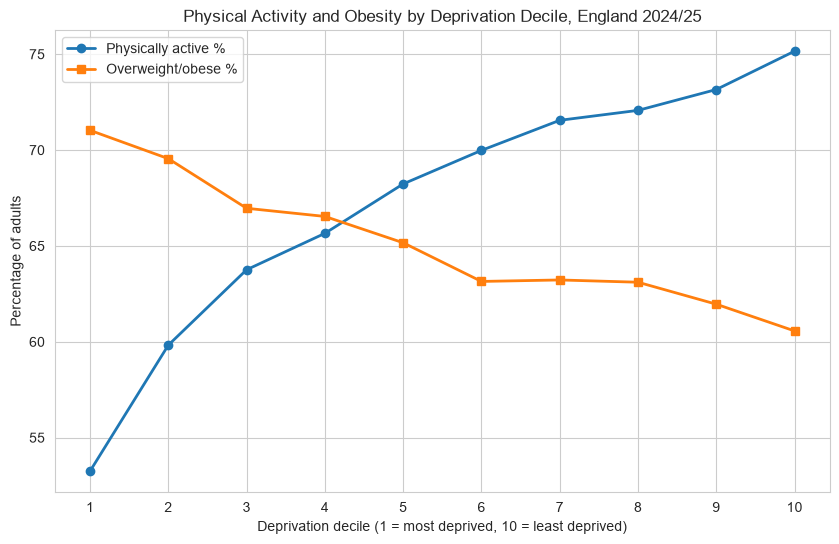

In [5]:
# Figure 1: activity and obesity across deprivation deciles, 2024/25
d = df[(df["year"] == "2024/25") & (df["dimension"] == "Deprivation")].copy()
d = d.sort_values("deprivation_rank")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(d["deprivation_rank"], d["pct_active"], marker="o",
        linewidth=2, label="Physically active %")
ax.plot(d["deprivation_rank"], d["pct_overweight_obese"], marker="s",
        linewidth=2, label="Overweight/obese %")
ax.set_xlabel("Deprivation decile (1 = most deprived, 10 = least deprived)")
ax.set_ylabel("Percentage of adults")
ax.set_title("Physical Activity and Obesity by Deprivation Decile, England 2024/25")
ax.set_xticks(range(1, 11))
ax.legend()
plt.show()

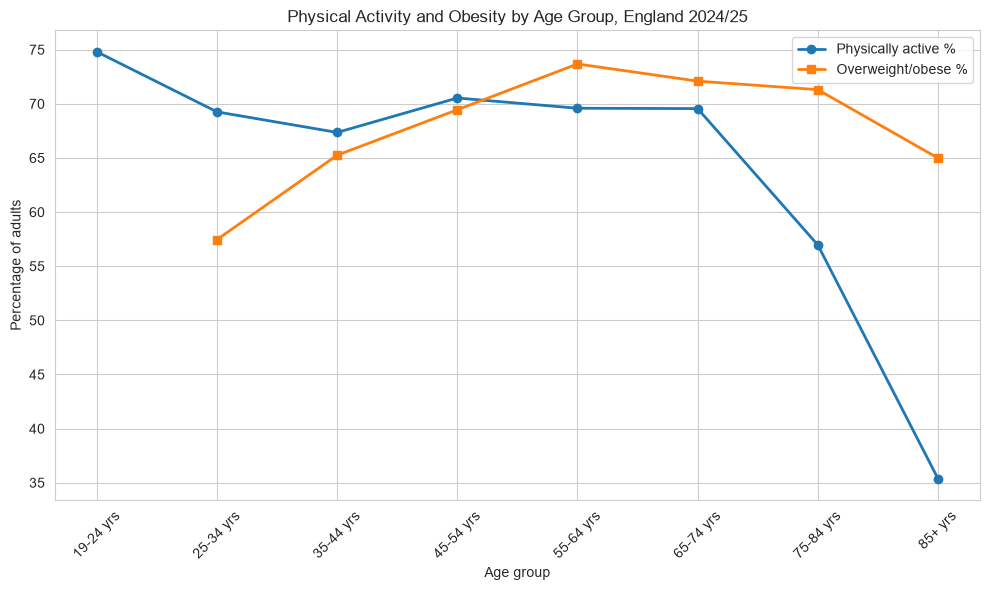

In [6]:

# Figure 2: activity and obesity across age groups, 2024/25
age_order = ["19-24 yrs", "25-34 yrs", "35-44 yrs", "45-54 yrs",
             "55-64 yrs", "65-74 yrs", "75-84 yrs", "85+ yrs"]

a = df[(df["year"] == "2024/25") & (df["dimension"] == "Age")].copy()
a = a[a["subgroup"].isin(age_order)]
a["subgroup"] = pd.Categorical(a["subgroup"], categories=age_order, ordered=True)
a = a.sort_values("subgroup")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(a["subgroup"], a["pct_active"], marker="o",
        linewidth=2, label="Physically active %")
ax.plot(a["subgroup"], a["pct_overweight_obese"], marker="s",
        linewidth=2, label="Overweight/obese %")
ax.set_xlabel("Age group")
ax.set_ylabel("Percentage of adults")
ax.set_title("Physical Activity and Obesity by Age Group, England 2024/25")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

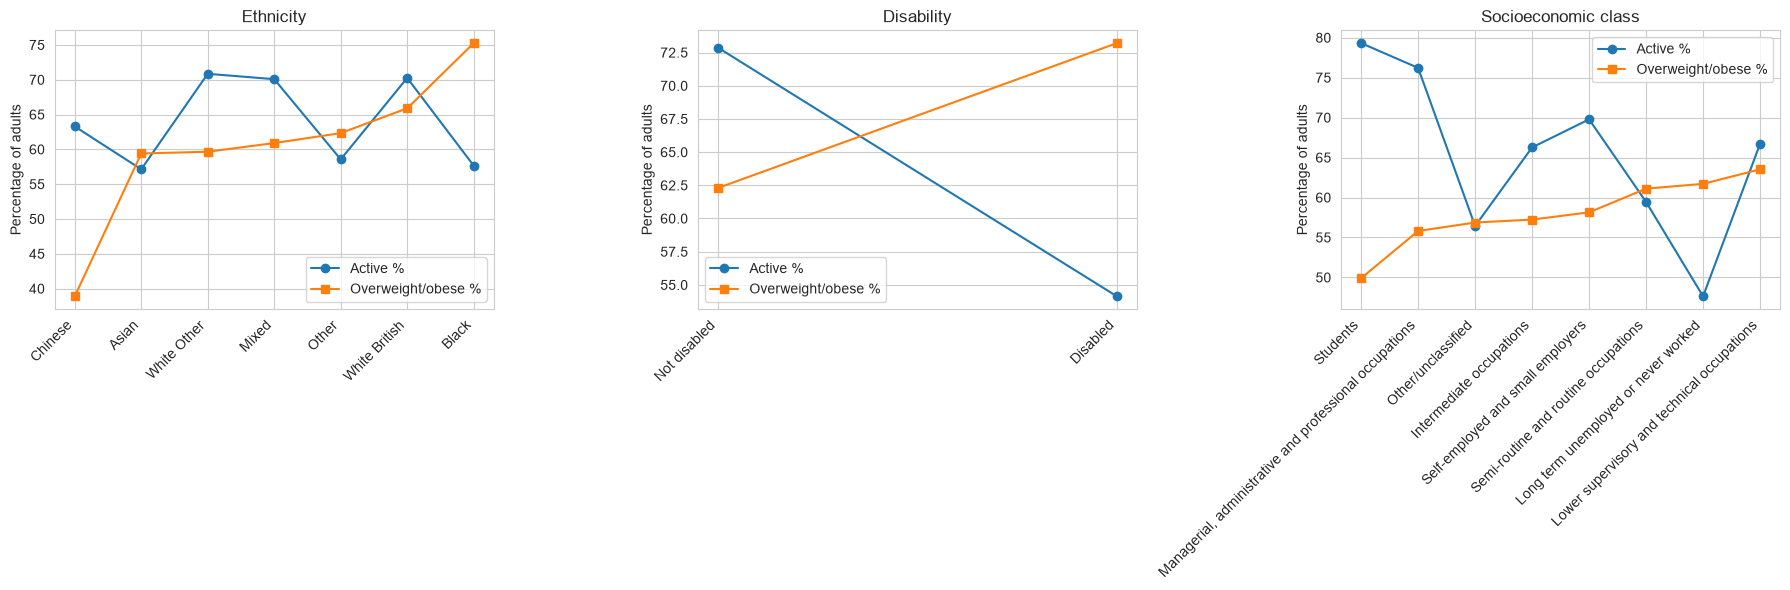

In [7]:
# Figure 3: activity and obesity across three more dimensions, 2024/25
dims = ["Ethnicity", "Disability", "Socioeconomic class"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, dim in zip(axes, dims):
    sub = df[(df["year"] == "2024/25") & (df["dimension"] == dim)].copy()
    sub = sub.sort_values("pct_overweight_obese")
    x = range(len(sub))
    ax.plot(x, sub["pct_active"], marker="o", label="Active %")
    ax.plot(x, sub["pct_overweight_obese"], marker="s", label="Overweight/obese %")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["subgroup"], rotation=45, ha="right")
    ax.set_title(dim)
    ax.set_ylabel("Percentage of adults")
    ax.legend()

plt.tight_layout()
plt.show()

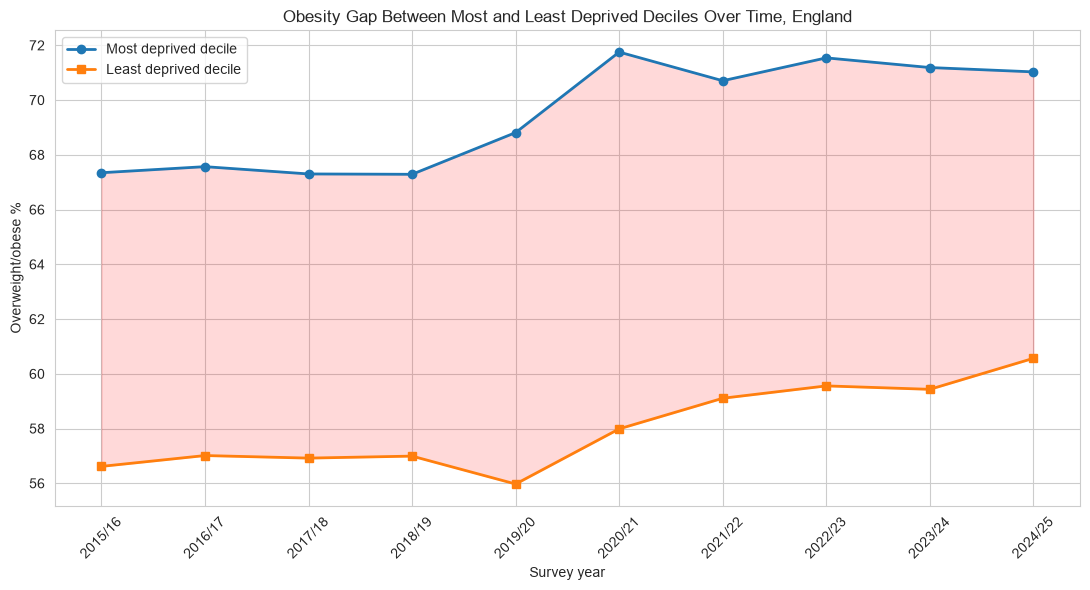

Obesity gap (most minus least deprived), percentage points:
   year      gap
2015/16 10.72769
2016/17 10.55333
2017/18 10.38035
2018/19 10.29442
2019/20 12.83852
2020/21 13.76477
2021/22 11.59853
2022/23 11.98292
2023/24 11.75481
2024/25 10.46342


In [8]:
# Figure 4: has the deprivation gap widened over 10 years?
# Compare most deprived vs least deprived decile, obesity, across all years
dep = df[df["dimension"] == "Deprivation"].copy()

most = dep[dep["subgroup"] == "Most deprived decile"].sort_values("year_numeric")
least = dep[dep["subgroup"] == "Least deprived decile"].sort_values("year_numeric")

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(most["year"], most["pct_overweight_obese"], marker="o",
        linewidth=2, label="Most deprived decile")
ax.plot(least["year"], least["pct_overweight_obese"], marker="s",
        linewidth=2, label="Least deprived decile")
ax.fill_between(most["year"], most["pct_overweight_obese"],
                least["pct_overweight_obese"], alpha=0.15, color="red")
ax.set_xlabel("Survey year")
ax.set_ylabel("Overweight/obese %")
ax.set_title("Obesity Gap Between Most and Least Deprived Deciles Over Time, England")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print the actual gap each year
gap = most[["year", "pct_overweight_obese"]].merge(
    least[["year", "pct_overweight_obese"]], on="year",
    suffixes=("_most", "_least"))
gap["gap"] = gap["pct_overweight_obese_most"] - gap["pct_overweight_obese_least"]
print("Obesity gap (most minus least deprived), percentage points:")
print(gap[["year", "gap"]].to_string(index=False))

In [9]:
from sklearn.model_selection import train_test_split

# Use the 10-year data, rows where activity and obesity both exist
model_df = df.dropna(subset=["pct_active", "pct_overweight_obese"]).copy()

# Features: activity, the demographic dimension, and year
# Target: is this subgroup above the national obesity average?
features = model_df[["pct_active", "pct_inactive", "dimension", "year_numeric"]].copy()
target = model_df["above_national_obesity"]

# Turn the text 'dimension' column into numbers the models can use
features = pd.get_dummies(features, columns=["dimension"])

print("Feature columns the models will use:")
print(features.columns.tolist())
print("\nTotal rows for modelling:", len(features))
print("Target balance:", target.value_counts().to_dict())

# Split into training and testing sets, 80/20, keeping class balance
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target)

print("\nTraining rows:", len(X_train))
print("Testing rows:", len(X_test))

Feature columns the models will use:
['pct_active', 'pct_inactive', 'year_numeric', 'dimension_Age', 'dimension_Deprivation', 'dimension_Disability', 'dimension_Education', 'dimension_Ethnicity', 'dimension_Sex', 'dimension_Socioeconomic class', 'dimension_Working status']

Total rows for modelling: 450
Target balance: {0: 230, 1: 220}

Training rows: 360
Testing rows: 90


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

# Predict on the unseen test set
y_pred_lr = logreg.predict(X_test)

# Measure how well it did
print("LOGISTIC REGRESSION RESULTS")
print("Accuracy: ", round(accuracy_score(y_test, y_pred_lr), 3))
print("Precision:", round(precision_score(y_test, y_pred_lr), 3))
print("Recall:   ", round(recall_score(y_test, y_pred_lr), 3))
print("F1 score: ", round(f1_score(y_test, y_pred_lr), 3))

LOGISTIC REGRESSION RESULTS
Accuracy:  0.844
Precision: 0.875
Recall:    0.795
F1 score:  0.833


In [11]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree, limited depth so it stays interpretable and doesn't overfit
dtree = DecisionTreeClassifier(max_depth=4, random_state=42)
dtree.fit(X_train, y_train)

y_pred_dt = dtree.predict(X_test)

print("DECISION TREE RESULTS")
print("Accuracy: ", round(accuracy_score(y_test, y_pred_dt), 3))
print("Precision:", round(precision_score(y_test, y_pred_dt), 3))
print("Recall:   ", round(recall_score(y_test, y_pred_dt), 3))
print("F1 score: ", round(f1_score(y_test, y_pred_dt), 3))

DECISION TREE RESULTS
Accuracy:  0.822
Precision: 0.868
Recall:    0.75
F1 score:  0.805


In [12]:
import numpy as np

# What did Logistic Regression weight most?
print("LOGISTIC REGRESSION - feature influence (coefficients):")
coefs = pd.Series(logreg.coef_[0], index=X_train.columns).sort_values()
for name, val in coefs.items():
    print(f"  {name:35s} {val:+.3f}")

print("\nDECISION TREE - feature importance:")
imp = pd.Series(dtree.feature_importances_, index=X_train.columns).sort_values(ascending=False)
for name, val in imp.items():
    print(f"  {name:35s} {val:.3f}")

LOGISTIC REGRESSION - feature influence (coefficients):
  dimension_Socioeconomic class       -3.266
  dimension_Ethnicity                 -0.849
  dimension_Disability                -0.201
  year_numeric                        -0.009
  dimension_Sex                       +0.125
  pct_active                          +0.150
  dimension_Deprivation               +0.223
  pct_inactive                        +0.309
  dimension_Age                       +1.037
  dimension_Education                 +1.263
  dimension_Working status            +1.673

DECISION TREE - feature importance:
  pct_inactive                        0.330
  dimension_Socioeconomic class       0.301
  dimension_Ethnicity                 0.180
  pct_active                          0.097
  dimension_Working status            0.089
  year_numeric                        0.002
  dimension_Age                       0.000
  dimension_Education                 0.000
  dimension_Disability                0.000
  dimension_Depr

In [13]:
# Remove the redundant activity variable to fix multicollinearity
features2 = model_df[["pct_inactive", "dimension", "year_numeric"]].copy()
features2 = pd.get_dummies(features2, columns=["dimension"])

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    features2, target, test_size=0.2, random_state=42, stratify=target)

# Retrain both models on the cleaned features
logreg2 = LogisticRegression(max_iter=1000, random_state=42).fit(X_train2, y_train2)
dtree2 = DecisionTreeClassifier(max_depth=4, random_state=42).fit(X_train2, y_train2)

lr_pred2 = logreg2.predict(X_test2)
dt_pred2 = dtree2.predict(X_test2)

print("LOGISTIC REGRESSION (cleaned)")
print("  Accuracy:", round(accuracy_score(y_test2, lr_pred2), 3),
      " F1:", round(f1_score(y_test2, lr_pred2), 3))
print("DECISION TREE (cleaned)")
print("  Accuracy:", round(accuracy_score(y_test2, dt_pred2), 3),
      " F1:", round(f1_score(y_test2, dt_pred2), 3))

print("\nLOGISTIC REGRESSION coefficients (now interpretable):")
coefs2 = pd.Series(logreg2.coef_[0], index=X_train2.columns).sort_values()
for name, val in coefs2.items():
    print(f"  {name:35s} {val:+.3f}")

LOGISTIC REGRESSION (cleaned)
  Accuracy: 0.811  F1: 0.8
DECISION TREE (cleaned)
  Accuracy: 0.811  F1: 0.779

LOGISTIC REGRESSION coefficients (now interpretable):
  dimension_Socioeconomic class       -3.175
  dimension_Ethnicity                 -0.964
  dimension_Disability                -0.197
  year_numeric                        -0.002
  dimension_Sex                       +0.139
  pct_inactive                        +0.148
  dimension_Deprivation               +0.248
  dimension_Age                       +1.048
  dimension_Education                 +1.238
  dimension_Working status            +1.665


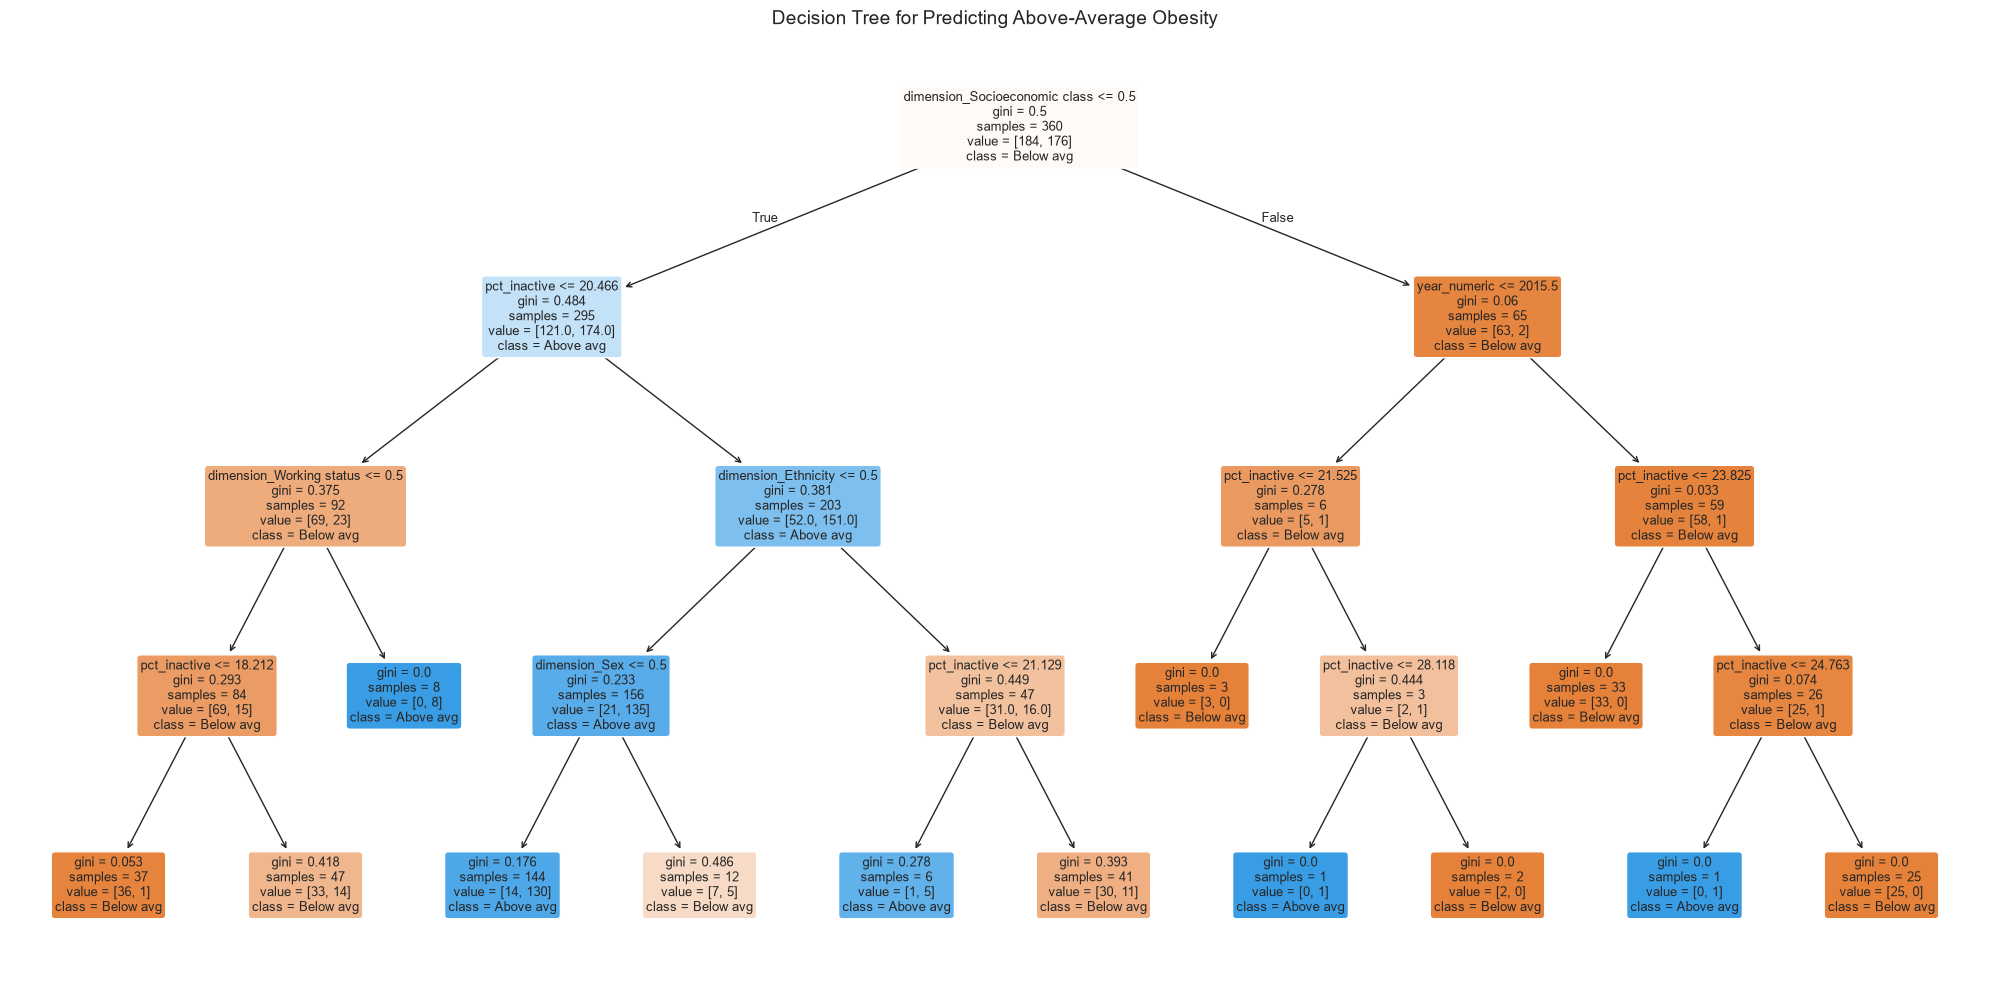

Saved to outputs/figures/decision_tree.png


In [14]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dtree2,
          feature_names=X_train2.columns,
          class_names=["Below avg", "Above avg"],
          filled=True,
          rounded=True,
          fontsize=9,
          ax=ax)
plt.title("Decision Tree for Predicting Above-Average Obesity", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/figures/decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/figures/decision_tree.png")

ROBUST DECISION TREE
  Accuracy: 0.789  F1: 0.747


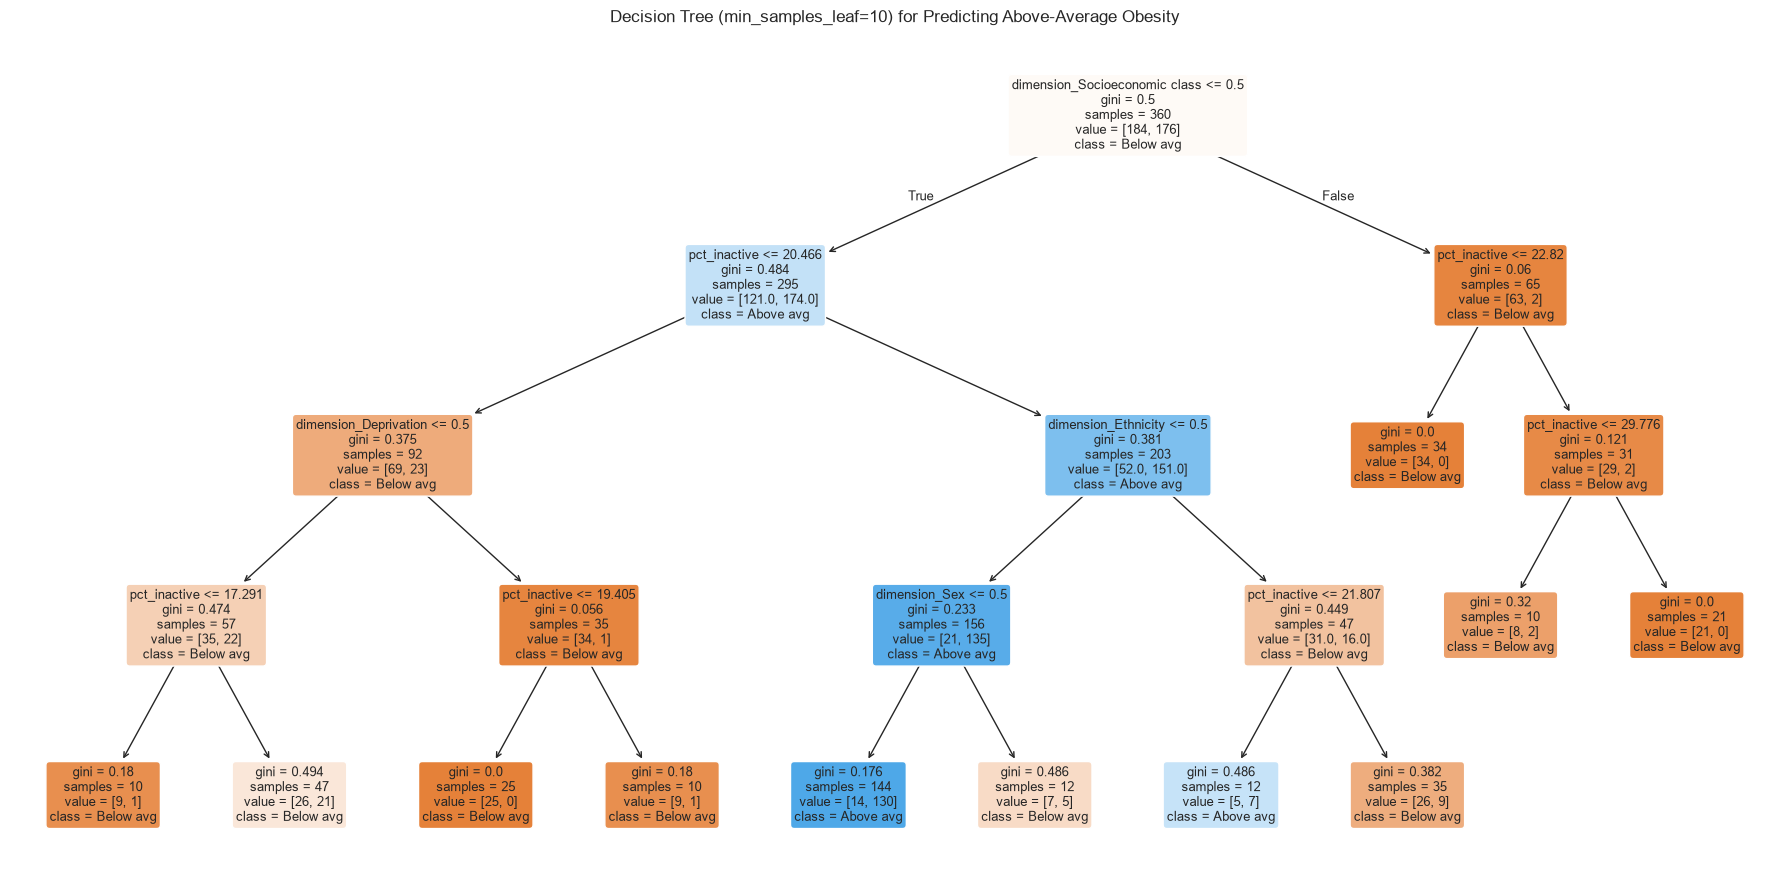

Saved.


In [15]:
# Retrain a more robust tree: limit depth AND require minimum leaf size
dtree3 = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=10,   # no leaf can have fewer than 10 subgroups
    random_state=42
).fit(X_train2, y_train2)

dt_pred3 = dtree3.predict(X_test2)
print("ROBUST DECISION TREE")
print("  Accuracy:", round(accuracy_score(y_test2, dt_pred3), 3),
      " F1:", round(f1_score(y_test2, dt_pred3), 3))

fig, ax = plt.subplots(figsize=(18, 9))
plot_tree(dtree3, feature_names=X_train2.columns,
          class_names=["Below avg", "Above avg"],
          filled=True, rounded=True, fontsize=9, ax=ax)
plt.title("Decision Tree (min_samples_leaf=10) for Predicting Above-Average Obesity")
plt.tight_layout()
plt.savefig("outputs/figures/decision_tree_robust.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

In [16]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Five-fold stratified cross-validation on the full modelling data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_scores = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42),
    features2, target, cv=cv, scoring="accuracy")

dt_scores = cross_val_score(
    DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42),
    features2, target, cv=cv, scoring="accuracy")

print("LOGISTIC REGRESSION - 5-fold cross-validation")
print("  Fold scores:", [round(s, 3) for s in lr_scores])
print("  Mean:", round(lr_scores.mean(), 3), " Std:", round(lr_scores.std(), 3))

print("\nDECISION TREE - 5-fold cross-validation")
print("  Fold scores:", [round(s, 3) for s in dt_scores])
print("  Mean:", round(dt_scores.mean(), 3), " Std:", round(dt_scores.std(), 3))

LOGISTIC REGRESSION - 5-fold cross-validation
  Fold scores: [np.float64(0.833), np.float64(0.733), np.float64(0.878), np.float64(0.844), np.float64(0.744)]
  Mean: 0.807  Std: 0.057

DECISION TREE - 5-fold cross-validation
  Fold scores: [np.float64(0.8), np.float64(0.789), np.float64(0.8), np.float64(0.767), np.float64(0.767)]
  Mean: 0.784  Std: 0.015


In [17]:
# Save the key results to a file for the write-up
results = {
    "Logistic Regression": {"accuracy": 0.811, "f1": 0.800,
                             "cv_mean": 0.807, "cv_std": 0.057},
    "Decision Tree (robust)": {"accuracy": 0.789, "f1": 0.747,
                               "cv_mean": 0.784, "cv_std": 0.015},
}
results_df = pd.DataFrame(results).T
results_df.to_csv("outputs/tables/model_results.csv")
print("Saved model results:")
print(results_df)

Saved model results:
                        accuracy     f1  cv_mean  cv_std
Logistic Regression        0.811  0.800    0.807   0.057
Decision Tree (robust)     0.789  0.747    0.784   0.015
